In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sys.path.append("..")
from src.data_preprocessing import load_data, remove_unwanted_columns, convert_to_datetime, sort_by_date_and_productId, drop_null_values
from src.split_data import split_data, split_features_and_target
from src.train_model import train_and_evaluate_model, train_model, hyperparameter_tuning
from features.features_engineering import lag_features, day_of_week_feature
from pipeline.train_model import run_pipeline


In [ ]:
df = load_data("../data/raw/stocksense_dataset.csv")
df.head()


,date,product_id,product_name,category,price,quantity_sold,stock_before,stock_after,reorder_level
0,2024-01-01,P001,Rice,Grains,1502,13,121,108,30
1,2024-01-01,P002,Milk,Dairy,1288,11,124,113,30
2,2024-01-01,P003,Bread,Bakery,902,14,180,166,30
3,2024-01-01,P004,Sugar,Groceries,1049,16,70,54,30
4,2024-01-01,P005,Eggs,Protein,2060,8,138,130,30


In [ ]:
df = remove_unwanted_columns(df, ["category", "stock_before", "reorder_level"])


df.head()

,date,product_id,product_name,price,quantity_sold,stock_after
0,2024-01-01,P001,Rice,1502,13,108
1,2024-01-01,P002,Milk,1288,11,113
2,2024-01-01,P003,Bread,902,14,166
3,2024-01-01,P004,Sugar,1049,16,54
4,2024-01-01,P005,Eggs,2060,8,130


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           900 non-null    object
 1   product_id     900 non-null    object
 2   product_name   900 non-null    object
 3   price          900 non-null    int64 
 4   quantity_sold  900 non-null    int64 
 5   stock_after    900 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 42.3+ KB


In [ ]:
df = convert_to_datetime(df, "date")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           900 non-null    datetime64[ns]
 1   product_id     900 non-null    object        
 2   product_name   900 non-null    object        
 3   price          900 non-null    int64         
 4   quantity_sold  900 non-null    int64         
 5   stock_after    900 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 42.3+ KB


In [ ]:
df.isnull().sum()

date             0
product_id       0
product_name     0
price            0
quantity_sold    0
stock_after      0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['product_name'].nunique()

5

In [ ]:
df = sort_by_date_and_productId(df, "date", "product_id")

df.head()

,date,product_id,product_name,price,quantity_sold,stock_after
0,2024-01-01,P001,Rice,1502,13,108
1,2024-01-01,P002,Milk,1288,11,113
2,2024-01-01,P003,Bread,902,14,166
3,2024-01-01,P004,Sugar,1049,16,54
4,2024-01-01,P005,Eggs,2060,8,130


In [ ]:
print((df['price'] < 0).sum())
print((df['stock_after'] < 0).sum())
print((df['quantity_sold'] < 0).sum())

0
0
0


In [ ]:
df.describe()

,date,price,quantity_sold,stock_after
count,900,900.000000,900.000000,900.000000
mean,2024-03-30 11:59:59.999999744,1320.036667,10.036667,116.388889
min,2024-01-01 00:00:00,700.000000,2.000000,36.000000
25%,2024-02-14 18:00:00,964.500000,7.000000,78.000000
50%,2024-03-30 12:00:00,1213.500000,10.000000,118.000000
75%,2024-05-14 06:00:00,1579.250000,12.000000,153.250000
max,2024-06-28 00:00:00,2149.000000,25.000000,196.000000
std,NaN,428.121527,3.785663,43.886646


In [ ]:
lag_features(df, "product_id", "quantity_sold")

df.head()

,date,product_id,product_name,price,quantity_sold,stock_after,quantity_sold_lag
0,2024-01-01,P001,Rice,1502,13,108,NaN
1,2024-01-01,P002,Milk,1288,11,113,NaN
2,2024-01-01,P003,Bread,902,14,166,NaN
3,2024-01-01,P004,Sugar,1049,16,54,NaN
4,2024-01-01,P005,Eggs,2060,8,130,NaN


In [ ]:
day_of_week_feature(df, "date")

,date,product_id,product_name,price,quantity_sold,stock_after,quantity_sold_lag,day_of_week
0,2024-01-01,P001,Rice,1502,13,108,NaN,0
1,2024-01-01,P002,Milk,1288,11,113,NaN,0
2,2024-01-01,P003,Bread,902,14,166,NaN,0
3,2024-01-01,P004,Sugar,1049,16,54,NaN,0
4,2024-01-01,P005,Eggs,2060,8,130,NaN,0
...,...,...,...,...,...,...,...,...
895,2024-06-28,P001,Rice,1613,11,136,5.0,4
896,2024-06-28,P002,Milk,1129,7,95,5.0,4
897,2024-06-28,P003,Bread,941,5,152,3.0,4
898,2024-06-28,P004,Sugar,1122,8,188,3.0,4


In [ ]:
df.isnull().sum()


date                 0
product_id           0
product_name         0
price                0
quantity_sold        0
stock_after          0
quantity_sold_lag    5
day_of_week          0
dtype: int64

In [ ]:
df = drop_null_values(df)
df.isnull().sum()

date                 0
product_id           0
product_name         0
price                0
quantity_sold        0
stock_after          0
quantity_sold_lag    0
day_of_week          0
dtype: int64

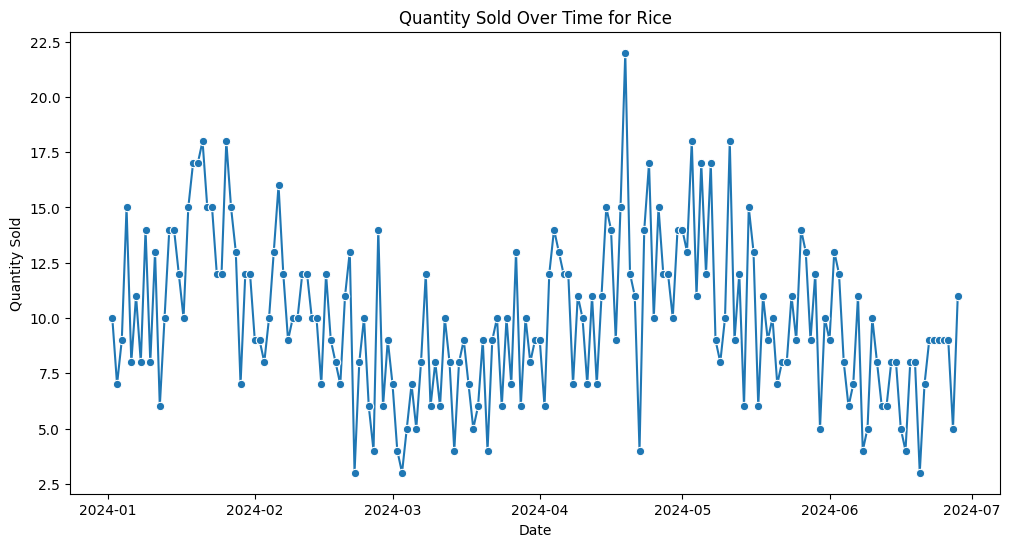

In [ ]:
sample = df[df['product_id'] == 'P001']

plt.figure(figsize=(12, 6))

sns.lineplot(x='date', y='quantity_sold', data=sample, marker='o')
plt.title(f'Quantity Sold Over Time for Rice')
plt.xlabel('Date')
plt.ylabel('Quantity Sold')
plt.show()


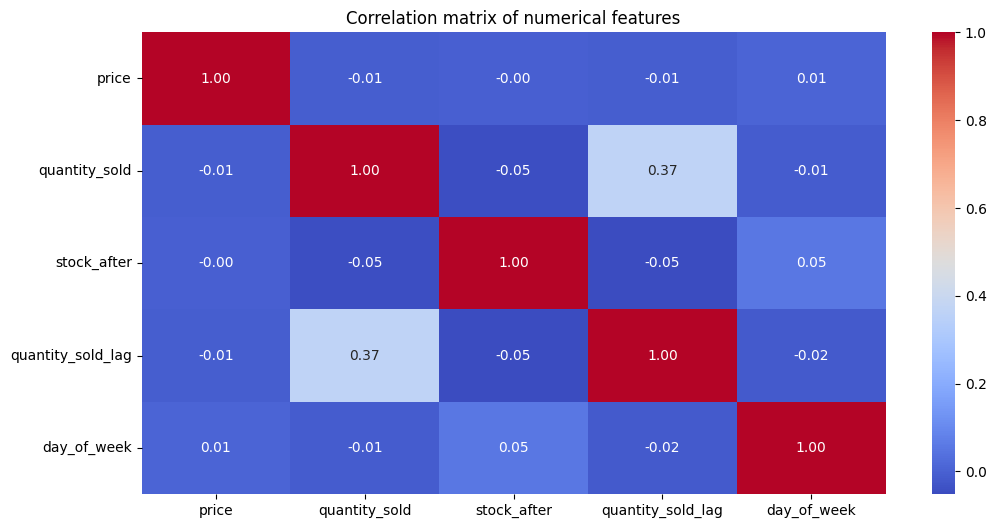

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns

correlation = df[num_cols].corr()

plt.figure(figsize=(12, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation matrix of numerical features")
plt.show()

In [ ]:
df.shape

(895, 8)

In [ ]:
train_df, val_df, test_df = split_data(df)

c:\Users\Lenovo ThinkPad T480\Desktop\StockSense\notebooks\..\src\split_data.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["date", "product_name"], inplace=True)


In [ ]:
test_df.max()

product_id           P005
price                2148
quantity_sold          13
stock_after           193
quantity_sold_lag    13.0
day_of_week             6
dtype: object

In [ ]:
train_df.head()

,product_id,price,quantity_sold,stock_after,quantity_sold_lag,day_of_week
5,P001,1448,10,54,13.0,1
6,P002,1289,5,152,11.0,1
7,P003,754,14,108,14.0,1
8,P004,1066,11,128,16.0,1
9,P005,1952,7,50,8.0,1


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 626 entries, 5 to 630
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         626 non-null    object 
 1   price              626 non-null    int64  
 2   quantity_sold      626 non-null    int64  
 3   stock_after        626 non-null    int64  
 4   quantity_sold_lag  626 non-null    float64
 5   day_of_week        626 non-null    int32  
dtypes: float64(1), int32(1), int64(3), object(1)
memory usage: 31.8+ KB


In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = df.select_dtypes(include=['object']).columns.tolist()

encode = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_df_encoded = encode.fit_transform(train_df[cat_cols])
encoded_cat_train_df = pd.DataFrame(train_df_encoded, columns=encode.get_feature_names_out(cat_cols), index=train_df.index)
train_df = pd.concat([train_df.drop(columns=cat_cols), encoded_cat_train_df], axis=1)
train_df.head()

,price,quantity_sold,stock_after,quantity_sold_lag,day_of_week,product_id_P001,product_id_P002,product_id_P003,product_id_P004,product_id_P005
5,1448,10,54,13.0,1,1.0,0.0,0.0,0.0,0.0
6,1289,5,152,11.0,1,0.0,1.0,0.0,0.0,0.0
7,754,14,108,14.0,1,0.0,0.0,1.0,0.0,0.0
8,1066,11,128,16.0,1,0.0,0.0,0.0,1.0,0.0
9,1952,7,50,8.0,1,0.0,0.0,0.0,0.0,1.0


In [ ]:
val_df_encoded = encode.transform(val_df[cat_cols])
encoded_cat_val_df = pd.DataFrame(val_df_encoded, columns=encode.get_feature_names_out(cat_cols), index=val_df.index)
val_df = pd.concat([val_df.drop(columns=cat_cols), encoded_cat_val_df], axis=1)
val_df.head()


,price,quantity_sold,stock_after,quantity_sold_lag,day_of_week,product_id_P001,product_id_P002,product_id_P003,product_id_P004,product_id_P005
631,1237,12,54,13.0,0,0.0,1.0,0.0,0.0,0.0
632,795,17,139,14.0,0,0.0,0.0,1.0,0.0,0.0
633,987,16,37,13.0,0,0.0,0.0,0.0,1.0,0.0
634,1970,9,170,13.0,0,0.0,0.0,0.0,0.0,1.0
635,1505,17,72,12.0,1,1.0,0.0,0.0,0.0,0.0


In [ ]:
test_df_encoded = encode.transform(test_df[cat_cols])
encoded_cat_test_df = pd.DataFrame(test_df_encoded, columns=encode.get_feature_names_out(cat_cols), index=test_df.index)
test_df = pd.concat([test_df.drop(columns=cat_cols), encoded_cat_test_df], axis=1)
test_df.head()

,price,quantity_sold,stock_after,quantity_sold_lag,day_of_week,product_id_P001,product_id_P002,product_id_P003,product_id_P004,product_id_P005
765,1633,13,170,9.0,6,1.0,0.0,0.0,0.0,0.0
766,1304,10,87,13.0,6,0.0,1.0,0.0,0.0,0.0
767,834,8,190,12.0,6,0.0,0.0,1.0,0.0,0.0
768,971,10,161,8.0,6,0.0,0.0,0.0,1.0,0.0
769,2044,7,174,9.0,6,0.0,0.0,0.0,0.0,1.0


In [ ]:
X_train, y_train = split_features_and_target(train_df)
X_val, y_val = split_features_and_target(val_df)
X_test, y_test =split_features_and_target(test_df)

In [ ]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(626, 9)
(134, 9)
(135, 9)


In [ ]:
X_train.head()

,price,stock_after,quantity_sold_lag,day_of_week,product_id_P001,product_id_P002,product_id_P003,product_id_P004,product_id_P005
5,1448,54,13.0,1,1.0,0.0,0.0,0.0,0.0
6,1289,152,11.0,1,0.0,1.0,0.0,0.0,0.0
7,754,108,14.0,1,0.0,0.0,1.0,0.0,0.0
8,1066,128,16.0,1,0.0,0.0,0.0,1.0,0.0
9,1952,50,8.0,1,0.0,0.0,0.0,0.0,1.0


In [ ]:
y_pred, evaluation_results = train_and_evaluate_model(X_train, y_train, X_val, y_val)

evaluation_results

{'Mean Squared Error': 12.515991791044776,
 'Mean Absolute Error': 2.7511194029850743,
 'R2 Score': -0.09835761636658669}

In [ ]:
error_analysis = pd.DataFrame({"Actual": y_val, "Predicted": y_pred, 'Error': y_val - y_pred})
error_analysis.head()

,Actual,Predicted,Error
631,12,11.72,0.28
632,17,13.09,3.91
633,16,13.71,2.29
634,9,10.05,-1.05
635,17,10.95,6.05


In [ ]:
error_analysis.sort_values(by='Error', ascending=False).head(10)

,Actual,Predicted,Error
699,20,10.91,9.09
655,18,10.31,7.69
649,18,11.36,6.64
663,17,10.53,6.47
635,17,10.95,6.05
703,14,8.03,5.97
727,13,7.35,5.65
651,17,11.53,5.47
654,17,11.55,5.45
675,15,9.80,5.20


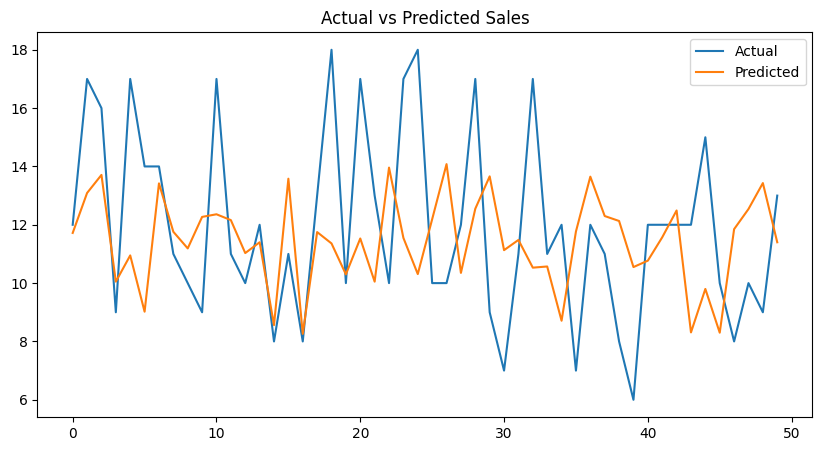

In [ ]:

plt.figure(figsize=(10, 5))

plt.plot(y_val.values[:50], label="Actual")
plt.plot(error_analysis['Predicted'].values[:50], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [ ]:
best_model = hyperparameter_tuning(X_train, y_train)

Best Hyperparameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
y_pred_best_model = best_model.predict(X_val)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_best_model = {
    "MAE": mean_absolute_error(y_val, y_pred_best_model),
    "MSE": mean_squared_error(y_val, y_pred_best_model),
    "R2 Score": r2_score(y_val, y_pred_best_model)
}

print("Evaluation results for the best model:", mae_best_model)

Evaluation results for the best model: {'MAE': 2.6645879283266347, 'MSE': 11.468546570726009, 'R2 Score': -0.006437658709930183}
